In [2]:
# SMOTE and Random Forest Comparison with One-Hot Encoding
!pip install imbalanced-learn --quiet

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

In [3]:
# 1. Load your data
train = pd.read_pickle('/content/Train_FI.pkl')
test  = pd.read_pickle('/content/Test_FI.pkl')

In [4]:
# 2. Separate features and target
TARGET_COL = 'fraud'
X_train = train.drop(TARGET_COL, axis=1)
y_train = train[TARGET_COL]
X_test  = test.drop(TARGET_COL, axis=1)
y_test  = test[TARGET_COL]

In [5]:
# 3. Identify categorical columns for one-hot encoding
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [6]:
# 4. Build a ColumnTransformer for OHE, passthrough numeric features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe, cat_cols)
    ],
    remainder='passthrough'
)

In [7]:
# 5. Fit on training data and transform both train & test
X_train_enc = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out()
)
X_test_enc = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out()
)

# Keep the same index for alignment
X_train_enc.index = X_train.index
X_test_enc.index  = X_test.index

In [8]:
# 7. Apply SMOTE on training data
smote = SMOTE(random_state=1000)
X_resampled, y_resampled = smote.fit_resample(X_train_enc, y_train)

# 1. RANDOM FOREST

In [ ]:
# 8. Random Forest WITH SMOTE
rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_resampled, y_resampled)
y_pred_sm = rf_sm.predict(X_test_enc)

print("\n=== Random Forest WITH SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print(classification_report(y_test, y_pred_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))


=== Random Forest WITH SMOTE ===
Accuracy: 0.8433333333333334
              precision    recall  f1-score   support

           0       0.85      1.00      0.91      3034
           1       0.55      0.02      0.04       566

    accuracy                           0.84      3600
   macro avg       0.70      0.51      0.48      3600
weighted avg       0.80      0.84      0.78      3600

Confusion Matrix:
 [[3024   10]
 [ 554   12]]



=== Feature Importances (Random Forest) ===
remainder__past_num_of_claims     0.055143
ohe__accident_site_Parking Lot    0.053247
ohe__high_education_ind_0         0.053193
ohe__high_education_ind_1         0.052922
ohe__address_change_ind_1         0.046961
ohe__address_change_ind_0         0.044665
ohe__marital_status_0.0           0.042639
ohe__marital_status_1.0           0.041527
ohe__accident_site_Local          0.035832
ohe__gender_F                     0.031345
remainder__claim_est_payout       0.030972
remainder__annual_income          0.030240
remainder__vehicle_price          0.029486
remainder__vehicle_weight         0.028489
ohe__witness_present_ind_1.0      0.028218
ohe__witness_present_ind_0.0      0.027669
remainder__safty_rating           0.027521
remainder__age_of_driver          0.025533
remainder__liab_prct              0.025149
ohe__gender_M                     0.024707
dtype: float64


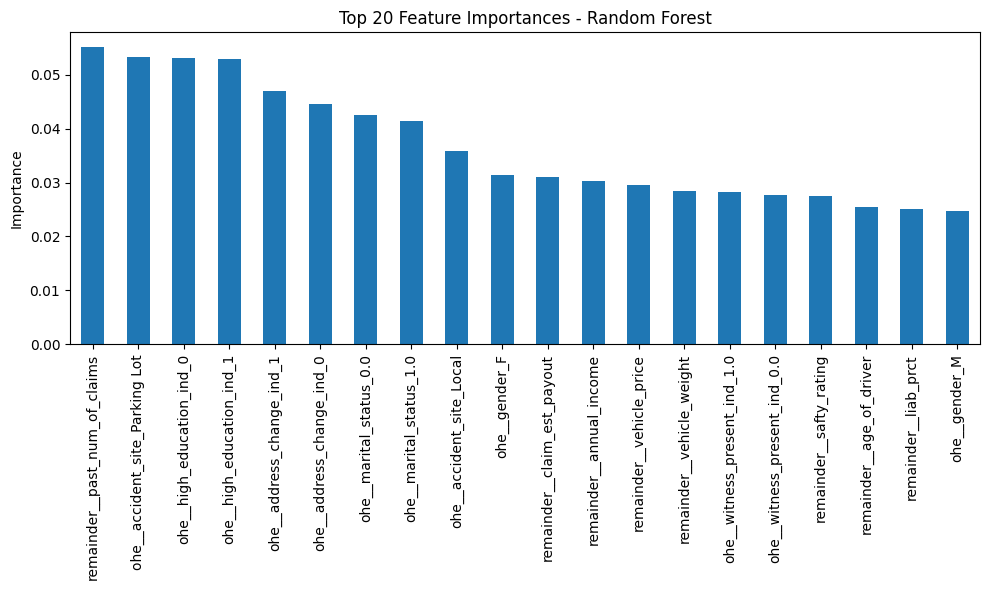

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importances
importances_rf = rf_sm.feature_importances_

# map to feature names
feat_importance_rf = pd.Series(importances_rf, index=X_train_enc.columns)

# sort descending
feat_importance_rf = feat_importance_rf.sort_values(ascending=False)

print("\n=== Feature Importances (Random Forest) ===")
print(feat_importance_rf.head(20))  # top 20 features

# optional: plot
plt.figure(figsize=(10,6))
feat_importance_rf.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
# 8.1 Hyperparameter Tuning

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300,400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit model on resampled data
grid_search.fit(X_resampled, y_resampled)

# Best estimator
best_rf = grid_search.best_estimator_

# Predict on original test set
y_pred_sm = best_rf.predict(X_test_enc)

# Evaluation
print("\n=== Tuned Random Forest WITH SMOTE ===")
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print(classification_report(y_test, y_pred_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))

Fitting 3 folds for each of 96 candidates, totalling 288 fits

=== Tuned Random Forest WITH SMOTE ===
Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Accuracy: 0.8430555555555556
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3034
           1       0.55      0.01      0.02       566

    accuracy                           0.84      3600
   macro avg       0.69      0.50      0.47      3600
weighted avg       0.80      0.84      0.77      3600

Confusion Matrix:
 [[3029    5]
 [ 560    6]]


In [ ]:
# 8.2 Check the Stability of Random Forest With SMOTE
metrics_smote = []

for seed in range(20):
    # Apply SMOTE with current seed
    smote = SMOTE(random_state=seed)
    X_resampled, y_resampled = smote.fit_resample(X_train_enc, y_train)

    # Train model with current seed
    rf_sm = RandomForestClassifier(random_state=seed)
    rf_sm.fit(X_resampled, y_resampled)

    # Predict on original test set
    y_pred_sm = rf_sm.predict(X_test_enc)

    # Evaluate
    acc = accuracy_score(y_test, y_pred_sm)
    prec = precision_score(y_test, y_pred_sm, zero_division=0)
    rec = recall_score(y_test, y_pred_sm, zero_division=0)
    f1 = f1_score(y_test, y_pred_sm, zero_division=0)

    metrics_smote.append({
        'Seed': seed,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

# Create and display table
metrics_smote_df = pd.DataFrame(metrics_smote)
print(metrics_smote_df)

    Seed  Accuracy  Precision    Recall        F1
0      0  0.843333   0.562500  0.015901  0.030928
1      1  0.842778   0.500000  0.015901  0.030822
2      2  0.841667   0.416667  0.017668  0.033898
3      3  0.842500   0.470588  0.014134  0.027444
4      4  0.842500   0.476190  0.017668  0.034072
5      5  0.842778   0.500000  0.012367  0.024138
6      6  0.841944   0.434783  0.017668  0.033956
7      7  0.842222   0.444444  0.014134  0.027397
8      8  0.842222   0.454545  0.017668  0.034014
9      9  0.842500   0.478261  0.019435  0.037351
10    10  0.843611   0.588235  0.017668  0.034305
11    11  0.841389   0.352941  0.010601  0.020583
12    12  0.841111   0.363636  0.014134  0.027211
13    13  0.841111   0.384615  0.017668  0.033784
14    14  0.840556   0.333333  0.014134  0.027119
15    15  0.842778   0.500000  0.019435  0.037415
16    16  0.841111   0.363636  0.014134  0.027211
17    17  0.843889   0.600000  0.021201  0.040956
18    18  0.842222   0.464286  0.022968  0.043771


In [ ]:
# 9.Check Class Imbalance
print("Original class distribution:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_resampled).value_counts())

Original class distribution:
 fraud
0    12148
1     2250
Name: count, dtype: int64
After SMOTE:
 fraud
0    12148
1    12148
Name: count, dtype: int64


# 2. Neural Network


In [35]:
# Model is overfitting
!pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd # Import pandas
import numpy as np # Import numpy


X_resampled = pd.DataFrame(X_resampled, columns=X_train_enc.columns) # Ensure it's a DataFrame
X_resampled_numeric = X_resampled.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply the same to the test set
X_test_enc = pd.DataFrame(X_test_enc, columns=X_test_enc.columns) # Ensure it's a DataFrame
X_test_numeric = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert target variable to numeric
y_resampled_numeric = y_resampled.astype(np.float32) # Convert to float32
y_test_numeric = y_test.astype(np.float32) # Convert to float32


# Optional: scale the data (neural networks often benefit from scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled_numeric) # Use numeric data
X_test_scaled = scaler.transform(X_test_numeric) # Use numeric data

# 3️⃣ Build Neural Network
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_resampled_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # because binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4️⃣ Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5️⃣ Train the model
history = model.fit(
    X_resampled_scaled, y_resampled_numeric, # Use numeric target variable
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 6️⃣ Evaluate on test set
y_pred_prob_test = model.predict(X_test_scaled).ravel()
y_pred_nn_test = (y_pred_prob_test > 0.5).astype(int)

# ✅ Evaluate on training set
y_pred_prob_train = model.predict(X_resampled_scaled).ravel()
y_pred_nn_train = (y_pred_prob_train > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🎯 Training Evaluation
print("\n=== Neural Network TRAINING SET ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_nn_train))
print("Classification Report:\n", classification_report(y_resampled_numeric, y_pred_nn_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_nn_train))

# 🧪 Test Evaluation
print("\n=== Neural Network TEST SET ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_nn_test))
print("Classification Report:\n", classification_report(y_test_numeric, y_pred_nn_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_nn_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6469 - loss: 0.6264 - val_accuracy: 0.4591 - val_loss: 0.7936
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6989 - loss: 0.5610 - val_accuracy: 0.5613 - val_loss: 0.7361
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7169 - loss: 0.5396 - val_accuracy: 0.6037 - val_loss: 0.7031
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7418 - loss: 0.5150 - val_accuracy: 0.7490 - val_loss: 0.5736
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7567 - loss: 0.4954 - val_accuracy: 0.7710 - val_loss: 0.5183
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7726 - loss: 0.4739 - val_accuracy: 0.7986 - val_loss: 0.4842
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7868 - loss: 0.4578 - val_accuracy: 0.7998 - val_loss: 0.4537
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7936 - loss: 0.4452 - val_accuracy: 0.

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
113/113 ━━━━━━━━

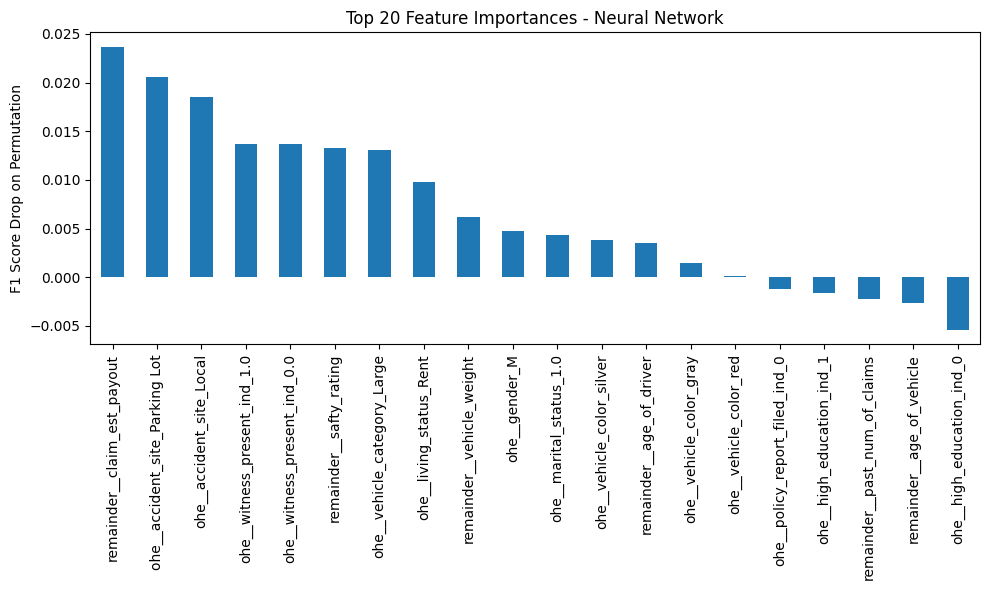

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def permutation_importance_nn(model, X_test_scaled, y_test_numeric, baseline_f1):
    importances = []
    X_test_copy = X_test_scaled.copy()

    for col in range(X_test_scaled.shape[1]):
        # permute one column
        X_test_permuted = X_test_copy.copy()
        np.random.shuffle(X_test_permuted[:, col])

        # predict & compute F1
        y_pred_perm = (model.predict(X_test_permuted).ravel() > 0.5).astype(int)
        f1 = f1_score(y_test_numeric, y_pred_perm)

        # drop in F1
        importances.append(baseline_f1 - f1)

    return np.array(importances)

# baseline F1 on original data
from sklearn.metrics import f1_score
y_pred_nn = (y_pred_prob > 0.5).astype(int)
baseline_f1 = f1_score(y_test_numeric, y_pred_nn)

# compute importances
importances = permutation_importance_nn(model, X_test_scaled, y_test_numeric, baseline_f1)

# map to feature names
feat_importance_nn = pd.Series(importances, index=X_test_enc.columns).sort_values(ascending=False)

print("\n=== Feature Importances (Neural Network - Permutation) ===")
print(feat_importance_nn.head(20))

# optional: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
feat_importance_nn.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances - Neural Network")
plt.ylabel("F1 Score Drop on Permutation")
plt.tight_layout()
plt.show()


## Treshold is 0.3  ( Best one  with good balance)

In [13]:
X_resampled = pd.DataFrame(X_resampled, columns=X_train_enc.columns) # Ensure it's a DataFrame
X_resampled_numeric = X_resampled.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply the same to the test set
X_test_enc = pd.DataFrame(X_test_enc, columns=X_test_enc.columns) # Ensure it's a DataFrame
X_test_numeric = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert target variable to numeric
y_resampled_numeric = y_resampled.astype(np.float32) # Convert to float32
y_test_numeric = y_test.astype(np.float32) # Convert to float32


# Optional: scale the data (neural networks often benefit from scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled_numeric) # Use numeric data
X_test_scaled = scaler.transform(X_test_numeric) # Use numeric data

# 3️⃣ Build Neural Network
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_resampled_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # because binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4️⃣ Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5️⃣ Train the model
history = model.fit(
    X_resampled_scaled, y_resampled_numeric, # Use numeric target variable
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 6️⃣ Evaluate on test set
y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_pred_prob > 0.3).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Neural Network WITH SMOTE ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print(classification_report(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation


# ✅ 7️⃣ Evaluate on TRAINING set
y_pred_prob_train = model.predict(X_resampled_scaled).ravel()
y_pred_nn_train = (y_pred_prob_train > 0.3).astype(int)

print("\n=== Neural Network TRAINING SET (threshold = 0.3) ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_nn_train))
print(classification_report(y_resampled_numeric, y_pred_nn_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_nn_train))




Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6468 - loss: 0.6198 - val_accuracy: 0.4951 - val_loss: 0.7783
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7025 - loss: 0.5579 - val_accuracy: 0.5091 - val_loss: 0.7781
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7279 - loss: 0.5374 - val_accuracy: 0.6490 - val_loss: 0.6597
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7421 - loss: 0.5188 - val_accuracy: 0.6722 - val_loss: 0.6258
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7649 - loss: 0.4914 - val_accuracy: 0.7800 - val_loss: 0.5184
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7759 - loss: 0.4730 - val_accuracy: 0.7447 - val_loss: 0.5307
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7983 - loss: 0.4436 - val_accuracy: 0.7907 - val_loss: 0.4790
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7934 - loss: 0.4422 - val_accuracy: 0.8537 - val

 ## Treshold is 0.2 ( best for detect for fraud cases well)

In [14]:
X_resampled = pd.DataFrame(X_resampled, columns=X_train_enc.columns) # Ensure it's a DataFrame
X_resampled_numeric = X_resampled.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply the same to the test set
X_test_enc = pd.DataFrame(X_test_enc, columns=X_test_enc.columns) # Ensure it's a DataFrame
X_test_numeric = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert target variable to numeric
y_resampled_numeric = y_resampled.astype(np.float32) # Convert to float32
y_test_numeric = y_test.astype(np.float32) # Convert to float32


# Optional: scale the data (neural networks often benefit from scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled_numeric) # Use numeric data
X_test_scaled = scaler.transform(X_test_numeric) # Use numeric data

# 3️⃣ Build Neural Network
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_resampled_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # because binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4️⃣ Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5️⃣ Train the model
history = model.fit(
    X_resampled_scaled, y_resampled_numeric, # Use numeric target variable
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 6️⃣ Evaluate on test set
y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_pred_prob > 0.2).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Neural Network WITH SMOTE in Test set ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print(classification_report(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation

# ✅ 7️⃣ Evaluate on TRAINING set
y_pred_prob_train = model.predict(X_resampled_scaled).ravel()
y_pred_nn_train = (y_pred_prob_train > 0.2).astype(int)

print("\n=== Neural Network TRAINING SET (threshold = 0.2) ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_nn_train))
print(classification_report(y_resampled_numeric, y_pred_nn_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_nn_train))



Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6424 - loss: 0.6164 - val_accuracy: 0.4872 - val_loss: 0.7795
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7029 - loss: 0.5566 - val_accuracy: 0.5150 - val_loss: 0.7709
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7321 - loss: 0.5304 - val_accuracy: 0.6912 - val_loss: 0.6187
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7475 - loss: 0.5128 - val_accuracy: 0.7200 - val_loss: 0.5884
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7676 - loss: 0.4844 - val_accuracy: 0.7716 - val_loss: 0.5251
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7791 - loss: 0.4635 - val_accuracy: 0.8261 - val_loss: 0.4514
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7880 - loss: 0.4552 - val_accuracy: 0.8049 - val_loss: 0.4536
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7965 - loss: 0.4360 - val_accuracy: 0.7930 - val_

## find best threshold

Best threshold by F1: 0.20 with F1: 0.35


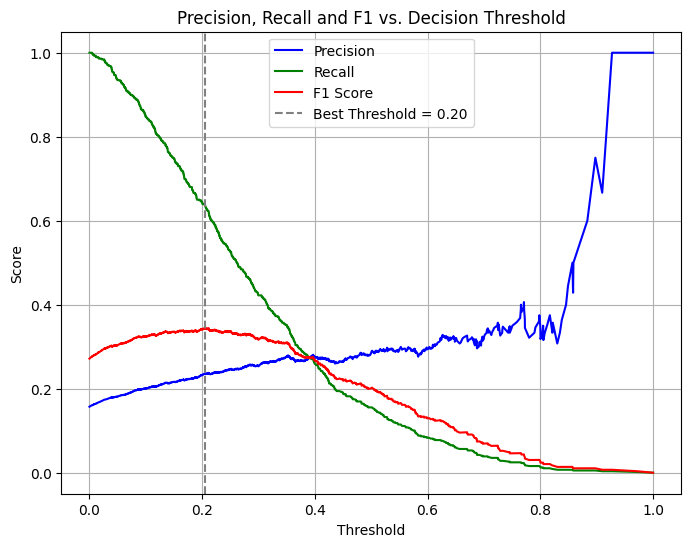

   Threshold  Precision  Recall        F1
0   0.000233   0.157222     1.0  0.271723
1   0.000337   0.157266     1.0  0.271789
2   0.000591   0.157310     1.0  0.271854
3   0.000667   0.157353     1.0  0.271919
4   0.000728   0.157397     1.0  0.271985
5   0.000749   0.157441     1.0  0.272050
6   0.000762   0.157485     1.0  0.272115
7   0.000777   0.157529     1.0  0.272181
8   0.000799   0.157572     1.0  0.272246
9   0.000856   0.157616     1.0  0.272312


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Assuming you already have:
# y_test → true labels
# y_pred_prob → predicted probabilities (from NN, shape: (n_samples,))

# compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# add a threshold of 1.0 at the end to align with precision & recall arrays
thresholds = np.append(thresholds, 1.0)

# Compute F1 for each point
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find the threshold that gives the maximum F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold by F1: {best_threshold:.2f} with F1: {best_f1:.2f}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision, label='Precision', color='blue')
plt.plot(thresholds, recall, label='Recall', color='green')
plt.plot(thresholds, f1_scores, label='F1 Score', color='red')
plt.axvline(x=best_threshold, color='gray', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs. Decision Threshold')
plt.legend()
plt.grid()
plt.show()

# Optional: also print table of values
import pandas as pd
df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision,
    'Recall': recall,
    'F1': f1_scores
})

print(df.head(10))


## Treshold as 0.23

In [17]:
X_resampled = pd.DataFrame(X_resampled, columns=X_train_enc.columns) # Ensure it's a DataFrame
X_resampled_numeric = X_resampled.apply(pd.to_numeric, errors='coerce').fillna(0)

# Apply the same to the test set
X_test_enc = pd.DataFrame(X_test_enc, columns=X_test_enc.columns) # Ensure it's a DataFrame
X_test_numeric = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert target variable to numeric
y_resampled_numeric = y_resampled.astype(np.float32) # Convert to float32
y_test_numeric = y_test.astype(np.float32) # Convert to float32


# Optional: scale the data (neural networks often benefit from scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled_numeric) # Use numeric data
X_test_scaled = scaler.transform(X_test_numeric) # Use numeric data

# 3️⃣ Build Neural Network
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_resampled_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # because binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4️⃣ Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5️⃣ Train the model
history = model.fit(
    X_resampled_scaled, y_resampled_numeric, # Use numeric target variable
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 6️⃣ Evaluate on test set
y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_pred_prob > 0.23).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Neural Network WITH SMOTE Test set ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print(classification_report(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation

# ✅ 7️⃣ Evaluate on TRAINING set
y_pred_prob_train = model.predict(X_resampled_scaled).ravel()
y_pred_nn_train = (y_pred_prob_train > 0.23).astype(int)

print("\n=== Neural Network TRAINING SET (threshold = 0.23) ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_nn_train))
print(classification_report(y_resampled_numeric, y_pred_nn_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_nn_train))


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6402 - loss: 0.6299 - val_accuracy: 0.5025 - val_loss: 0.7616
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7037 - loss: 0.5590 - val_accuracy: 0.5401 - val_loss: 0.7451
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7300 - loss: 0.5330 - val_accuracy: 0.6315 - val_loss: 0.6824
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7484 - loss: 0.5142 - val_accuracy: 0.6556 - val_loss: 0.6526
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7627 - loss: 0.4904 - val_accuracy: 0.7021 - val_loss: 0.6001
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7865 - loss: 0.4703 - val_accuracy: 0.7794 - val_loss: 0.4944
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7993 - loss: 0.4437 - val_accuracy: 0.8010 - val_loss: 0.4600
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8004 - loss: 0.4372 - val_accuracy: 0.8095 - val_

##  Plot Full Precision-Recall Curve + Mark Points



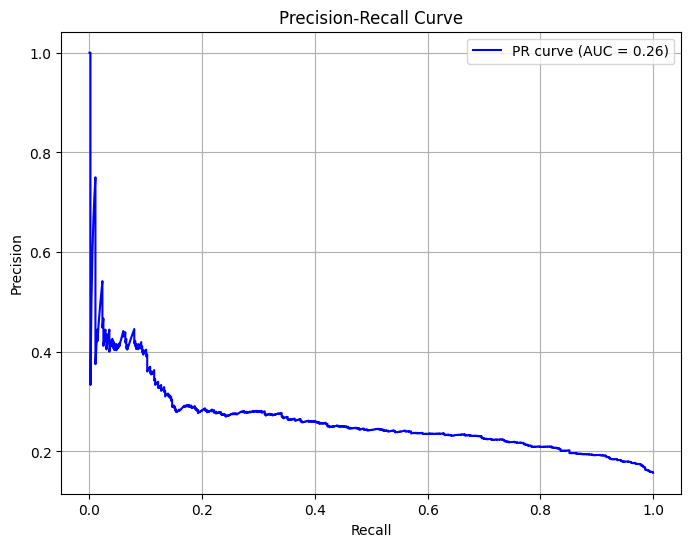

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# predicted probabilities from your NN
# y_pred_prob — predicted probabilities (shape: (n_samples,))
# y_test — true labels

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='b', label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.legend()
plt.show()


## Retrain NN with class_weight

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# (X_resampled_scaled, y_resampled) — your training data
# (X_test_scaled, y_test) — test data

# Convert y_resampled to a numerical type (float32)
y_resampled_numeric = y_resampled.astype(np.float32)
y_test_numeric = y_test.astype(np.float32)


model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_resampled_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with class weights
history = model.fit(
    X_resampled_scaled, y_resampled_numeric, # Use the numeric target variable
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    class_weight={0: 2, 1: 1}  # Here you give higher weight to class 0
)

# Predict probabilities
y_pred_prob = model.predict(X_test_scaled).ravel()

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# You can pick your chosen threshold here:
threshold = 0.5  # or whatever you pick from the PR curve
y_pred_nn = (y_pred_prob > threshold).astype(int)

print("=== NN WITH class_weight & chosen threshold ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print(classification_report(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_nn)) # Use numeric target variable for evaluation

# Predict on training set
y_train_pred_prob = model.predict(X_resampled_scaled).ravel()
y_train_pred_nn = (y_train_pred_prob > threshold).astype(int)

print("\n=== TRAINING SET PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_train_pred_nn))
print(classification_report(y_resampled_numeric, y_train_pred_nn))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_train_pred_nn))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6242 - loss: 0.8416 - val_accuracy: 0.0903 - val_loss: 1.1047
Epoch 2/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6540 - loss: 0.7441 - val_accuracy: 0.2043 - val_loss: 1.0065
Epoch 3/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6844 - loss: 0.7078 - val_accuracy: 0.3173 - val_loss: 0.9971
Epoch 4/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7161 - loss: 0.6817 - val_accuracy: 0.4617 - val_loss: 0.8524
Epoch 5/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7433 - loss: 0.6497 - val_accuracy: 0.5387 - val_loss: 0.7867
Epoch 6/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7684 - loss: 0.6294 - val_accuracy: 0.5907 - val_loss: 0.7470
Epoch 7/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7850 - loss: 0.5946 - val_accuracy: 0.6455 - val_loss: 0.6700
Epoch 8/50
608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7982 - loss: 0.5723 - val_accuracy: 0.

## Use Keras Tuner

In [37]:
!pip install keras-tuner --quiet
from kerastuner import Hyperband
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np # Import numpy

import tensorflow as tf

def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_1', min_value=64, max_value=256, step=32),
        activation='relu',
        input_dim=X_resampled_scaled.shape[1]
    ))
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_2', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))

    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

import kerastuner as kt

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='my_dir',
    project_name='fraud_nn_tuning'
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Convert y_resampled to a numerical type (float32) before using it in tuner.search
y_resampled_numeric = y_resampled.astype(np.float32)

tuner.search(
    X_resampled_scaled, y_resampled_numeric, # Use the numeric target variable
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

best_model = tuner.get_best_models(num_models=1)[0]

Trial 30 Complete [00h 00m 50s]
val_accuracy: 0.699999988079071

Best val_accuracy So Far: 0.9506173133850098
Total elapsed time: 00h 09m 54s


In [38]:
# 1. Best model from tuner
best_model = tuner.get_best_models(num_models=1)[0]

# 2. Evaluate on TRAINING SET
y_pred_prob_train = best_model.predict(X_resampled_scaled).ravel()
y_pred_train = (y_pred_prob_train > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Tuned Neural Network - TRAINING SET ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_train))
print("Classification Report:\n", classification_report(y_resampled_numeric, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_train))

# 3. Evaluate on TEST SET
y_pred_prob_test = best_model.predict(X_test_scaled).ravel()
y_pred_test = (y_pred_prob_test > 0.5).astype(int)

print("\n=== Tuned Neural Network - TEST SET ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_test))
print("Classification Report:\n", classification_report(y_test_numeric, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_test))


760/760 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Tuned Neural Network - TRAINING SET ===
Accuracy: 0.9059104379321699
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.90      0.91     12148
         1.0       0.90      0.91      0.91     12148

    accuracy                           0.91     24296
   macro avg       0.91      0.91      0.91     24296
weighted avg       0.91      0.91      0.91     24296

Confusion Matrix:
 [[10990  1158]
 [ 1128 11020]]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== Tuned Neural Network - TEST SET ===
Accuracy: 0.7516666666666667
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.84      0.85      3034
         1.0       0.26      0.30      0.28       566

    accuracy                           0.75      3600
   macro avg       0.56      0.57      0.56      3600
weighted avg       0.77      0.75      0.76      3600

Confusion Matrix:
 [[2

### find best threshold

In [39]:
from sklearn.metrics import precision_recall_curve
import numpy as np

prec, rec, thresholds = precision_recall_curve(y_test_numeric, y_pred_prob_test)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest threshold for max F1: {best_thresh:.3f}")

# Apply threshold
y_pred_test_best = (y_pred_prob_test >= best_thresh).astype(int)
y_pred_train_best = (y_pred_prob_train >= best_thresh).astype(int)

# Re-evaluate
print("\n=== Tuned NN - TEST SET (Best Threshold) ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_test_best))
print(classification_report(y_test_numeric, y_pred_test_best))
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_test_best))

print("\n=== Tuned NN - TRAIN SET (Best Threshold) ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_train_best))
print(classification_report(y_resampled_numeric, y_pred_train_best))
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_train_best))



Best threshold for max F1: 0.221

=== Tuned NN - TEST SET (Best Threshold) ===
Accuracy: 0.6036111111111111
              precision    recall  f1-score   support

         0.0       0.90      0.60      0.72      3034
         1.0       0.23      0.64      0.34       566

    accuracy                           0.60      3600
   macro avg       0.56      0.62      0.53      3600
weighted avg       0.79      0.60      0.66      3600

Confusion Matrix:
 [[1809 1225]
 [ 202  364]]

=== Tuned NN - TRAIN SET (Best Threshold) ===
Accuracy: 0.8165130062561738
              precision    recall  f1-score   support

         0.0       0.97      0.65      0.78     12148
         1.0       0.74      0.98      0.84     12148

    accuracy                           0.82     24296
   macro avg       0.86      0.82      0.81     24296
weighted avg       0.86      0.82      0.81     24296

Confusion Matrix:
 [[ 7916  4232]
 [  226 11922]]


## Dropout + EarlyStopping

In [42]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming X_resampled and X_test_enc are already defined and preprocessed
# Ensure X_resampled and X_test_enc contain only numerical data after one-hot encoding
# If there are still categorical columns, you might need to re-run the preprocessing steps
# or explicitly select only numerical columns before scaling.

# Convert to numeric and handle potential non-numeric values (if any survived preprocessing)
X_train_numeric = X_resampled.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_numeric = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert y_resampled and y_test to a numerical format
y_resampled_numeric = y_resampled.astype(np.float32) # Convert to float32 or int32
y_test_numeric = y_test.astype(np.float32) # Convert to float32 or int32


# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# Build a smaller, regularized model
def build_model():
    model = Sequential()
    model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
    model.add(Dropout(0.3))  # Dropout added
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))  # Dropout added
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Create the model
model = build_model()

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model
history = model.fit(
    X_train_scaled,
    y_resampled_numeric, # Use the numeric target variable
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Predict probabilities
y_proba_test = model.predict(X_test_scaled).ravel()
y_proba_train = model.predict(X_train_scaled).ravel()

# Find best threshold (maximize F1)
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test_numeric, y_proba_test > t) for t in thresholds] # Use numeric target for evaluation
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"\nBest threshold for max F1: {best_threshold:.3f}")

# Evaluate test
y_pred_test = (y_proba_test > best_threshold).astype(int)
print("\n=== NN - TEST SET (Best Threshold) ===")
print("Accuracy:", accuracy_score(y_test_numeric, y_pred_test)) # Use numeric target for evaluation
print(classification_report(y_test_numeric, y_pred_test)) # Use numeric target for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_numeric, y_pred_test)) # Use numeric target for evaluation

# Evaluate train
y_pred_train = (y_proba_train > best_threshold).astype(int)
print("\n=== NN - TRAIN SET (Best Threshold) ===")
print("Accuracy:", accuracy_score(y_resampled_numeric, y_pred_train)) # Use numeric target for evaluation
print(classification_report(y_resampled_numeric, y_pred_train)) # Use numeric target for evaluation
print("Confusion Matrix:\n", confusion_matrix(y_resampled_numeric, y_pred_train)) # Use numeric target for evaluation

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


304/304 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6148 - loss: 0.6506 - val_accuracy: 0.3792 - val_loss: 0.8202
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6811 - loss: 0.5834 - val_accuracy: 0.4877 - val_loss: 0.7848
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7020 - loss: 0.5624 - val_accuracy: 0.5901 - val_loss: 0.7178
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7086 - loss: 0.5545 - val_accuracy: 0.5730 - val_loss: 0.7370
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7195 - loss: 0.5414 - val_accuracy: 0.6325 - val_loss: 0.6889
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7341 - loss: 0.5323 - val_accuracy: 0.6471 - val_loss: 0.6704
Epoch 7/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7419 - loss: 0.5184 - val_accuracy: 0.7340 - val_loss: 0.5856
Epoch 8/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7504 - loss: 0.5064 - val_accuracy: 0.723

# XG boost

In [10]:
# 0. Install XGBoost (if not already installed)
!pip install xgboost --quiet

# 1. Import
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Train XGBoost on resampled data (after SMOTE)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_resampled, y_resampled)

# 3. Predict on test set
y_pred_xgb_test = xgb.predict(X_test_enc)

# 4. Predict on training set
y_pred_xgb_train = xgb.predict(X_resampled)

# 5. Evaluation on test set
print("\n=== XGBoost WITH SMOTE - TEST SET ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_test))
print(classification_report(y_test, y_pred_xgb_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_test))

# 6. Evaluation on training set
print("\n=== XGBoost WITH SMOTE - TRAINING SET ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_xgb_train))
print(classification_report(y_resampled, y_pred_xgb_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_xgb_train))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:25:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost WITH SMOTE - TEST SET ===
Accuracy: 0.8361111111111111
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3034
           1       0.40      0.09      0.15       566

    accuracy                           0.84      3600
   macro avg       0.63      0.53      0.53      3600
weighted avg       0.78      0.84      0.79      3600

Confusion Matrix:
 [[2959   75]
 [ 515   51]]

=== XGBoost WITH SMOTE - TRAINING SET ===
Accuracy: 0.9585528482054659
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     12148
           1       1.00      0.92      0.96     12148

    accuracy                           0.96     24296
   macro avg       0.96      0.96      0.96     24296
weighted avg       0.96      0.96      0.96     24296

Confusion Matrix:
 [[12127    21]
 [  986 11162]]


## Treshold with 0.3

In [ ]:

# 1. Import
from xgboost import XGBClassifier

# 2. Train XGBoost on resampled data (after SMOTE)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_resampled, y_resampled)

# 3. Predict probabilities on test set
y_proba_xgb = xgb.predict_proba(X_test_enc)[:, 1]

# 4. Apply custom threshold 0.3
threshold = 0.3
y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

# 5. Evaluation with threshold 0.3
print("\n=== XGBoost WITH SMOTE (Threshold = 0.3) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:42:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost WITH SMOTE (Threshold = 0.3) ===
Accuracy: 0.7872222222222223
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      3034
           1       0.30      0.25      0.27       566

    accuracy                           0.79      3600
   macro avg       0.58      0.57      0.57      3600
weighted avg       0.77      0.79      0.78      3600

Confusion Matrix:
 [[2690  344]
 [ 422  144]]



=== Feature Importances (XGBoost) ===
ohe__address_change_ind_1         0.190781
ohe__gender_M                     0.119000
ohe__marital_status_1.0           0.098479
ohe__high_education_ind_1         0.096556
ohe__witness_present_ind_1.0      0.069672
ohe__accident_site_Parking Lot    0.051817
ohe__witness_present_ind_0.0      0.051312
ohe__high_education_ind_0         0.033833
ohe__policy_report_filed_ind_1    0.027345
ohe__marital_status_0.0           0.026564
remainder__past_num_of_claims     0.022087
ohe__address_change_ind_0         0.020873
ohe__accident_site_Highway        0.020212
ohe__gender_F                     0.017732
ohe__living_status_Rent           0.014294
ohe__accident_site_Local          0.012990
ohe__vehicle_category_Large       0.012168
ohe__policy_report_filed_ind_0    0.009244
ohe__living_status_Own            0.009164
ohe__channel_Broker               0.006232
dtype: float32


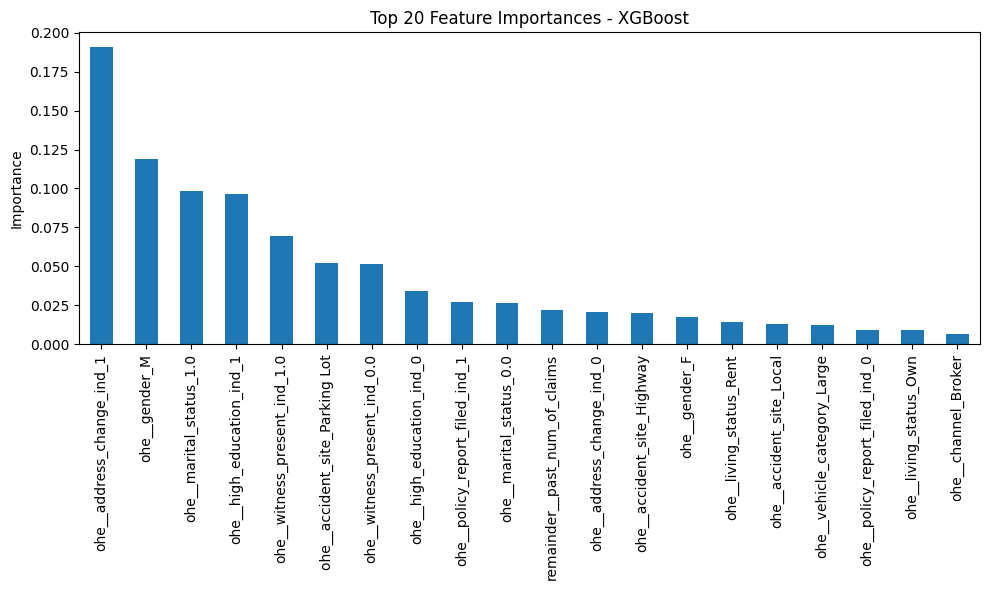

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importances
importances_xgb = xgb.feature_importances_

# map to feature names
feat_importance_xgb = pd.Series(importances_xgb, index=X_train_enc.columns)

# sort descending
feat_importance_xgb = feat_importance_xgb.sort_values(ascending=False)

print("\n=== Feature Importances (XGBoost) ===")
print(feat_importance_xgb.head(20))  # top 20

# optional: plot
plt.figure(figsize=(10,6))
feat_importance_xgb.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances - XGBoost")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## Treshold as 0.2( best one as good balance)

In [ ]:
# 0. Install XGBoost (if not already installed)
!pip install xgboost --quiet

# 1. Import
from xgboost import XGBClassifier

# 2. Train XGBoost on resampled data (after SMOTE)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_resampled, y_resampled)

# 3. Predict probabilities on test set
y_proba_xgb = xgb.predict_proba(X_test_enc)[:, 1]

# 4. Apply custom threshold 0.3
threshold = 0.2

y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

# 5. Evaluation with threshold 0.3
print("\n=== XGBoost WITH SMOTE (Threshold = 0.3) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:55:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost WITH SMOTE (Threshold = 0.3) ===
Accuracy: 0.7197222222222223
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      3034
           1       0.26      0.43      0.32       566

    accuracy                           0.72      3600
   macro avg       0.57      0.60      0.57      3600
weighted avg       0.78      0.72      0.74      3600

Confusion Matrix:
 [[2350  684]
 [ 325  241]]


## RandomizedSearchCV

In [11]:
from xgboost import XGBClassifier, callback
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
import numpy as np

# Split training data for early stopping validation
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Base XGB model (no use_label_encoder)
xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=np.sum(y_resampled == 0) / np.sum(y_resampled == 1)
)

param_dist = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.2]
}

f1 = make_scorer(f1_score, pos_label=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f1,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_resampled, y_resampled)

print("Best hyperparameters:", random_search.best_params_)
print("Best CV F1 score:", random_search.best_score_)

# Retrain best model with early stopping using callbacks
best_params = random_search.best_params_

final_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=np.sum(y_resampled == 0) / np.sum(y_resampled == 1),
    **best_params
)

final_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val_sub, y_val_sub)],
    verbose=True
)

# Evaluate on test set
y_pred_test = final_model.predict(X_test_enc)
print("\n=== Test set evaluation ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

# Evaluate on full training data
y_pred_train = final_model.predict(X_resampled)
print("\n=== Training set evaluation ===")
print(classification_report(y_resampled, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters: {'subsample': 1.0, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV F1 score: 0.8601175303649122
[0]	validation_0-logloss:0.66451
[1]	validation_0-logloss:0.63142
[2]	validation_0-logloss:0.60368
[3]	validation_0-logloss:0.57784
[4]	validation_0-logloss:0.56061
[5]	validation_0-logloss:0.53980
[6]	validation_0-logloss:0.52020
[7]	validation_0-logloss:0.50391
[8]	validation_0-logloss:0.49217
[9]	validation_0-logloss:0.47728
[10]	validation_0-logloss:0.46463
[11]	validation_0-logloss:0.44999
[12]	validation_0-logloss:0.44251
[13]	validation_0-logloss:0.43087
[14]	validation_0-logloss:0.41945
[15]	validation_0-logloss:0.41143
[16]	validation_0-logloss:0.40116
[17]	validation_0-logloss:0.39140
[18]	validation_0-logloss:0.38633
[19]	validation_0-logloss:0.38043
[20]	validation_0-logloss:0.37232
[21]	validation_0-logloss:0.36584
[22]	validation_0-logloss

### tresold with 0.3

In [12]:
# Predict probabilities on test set
y_pred_prob_test = final_model.predict_proba(X_test_enc)[:, 1]  # get positive class probabilities

# Apply threshold 0.3
threshold = 0.3
y_pred_test = (y_pred_prob_test > threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Test set evaluation with threshold 0.3 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

# Similarly for training set
y_pred_prob_train = final_model.predict_proba(X_resampled)[:, 1]
y_pred_train = (y_pred_prob_train > threshold).astype(int)

print("\n=== Training set evaluation with threshold 0.3 ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train))
print(classification_report(y_resampled, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train))


=== Test set evaluation with threshold 0.3 ===
Accuracy: 0.8036111111111112
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      3034
           1       0.35      0.28      0.31       566

    accuracy                           0.80      3600
   macro avg       0.61      0.59      0.60      3600
weighted avg       0.79      0.80      0.79      3600

Confusion Matrix:
 [[2736  298]
 [ 409  157]]

=== Training set evaluation with threshold 0.3 ===
Accuracy: 0.8910931840632202
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     12148
           1       0.91      0.87      0.89     12148

    accuracy                           0.89     24296
   macro avg       0.89      0.89      0.89     24296
weighted avg       0.89      0.89      0.89     24296

Confusion Matrix:
 [[11063  1085]
 [ 1561 10587]]


## use strong regularization

In [14]:
# === CONTINUED: Strong Regularization ===
final_model_strong_reg = XGBClassifier(
    random_state=42,
    scale_pos_weight=np.sum(y_resampled == 0) / np.sum(y_resampled == 1),
    **best_params,
    reg_alpha=50,      # L1 regularization (increased)
    reg_lambda=50      # L2 regularization (increased)
)

final_model_strong_reg.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val_sub, y_val_sub)],
    verbose=True
)

# === Predict probabilities for threshold control ===
y_proba_test = final_model_strong_reg.predict_proba(X_test_enc)[:, 1]
y_proba_train = final_model_strong_reg.predict_proba(X_resampled)[:, 1]

# Set custom threshold
threshold = 0.3
y_pred_test_thresh = (y_proba_test >= threshold).astype(int)
y_pred_train_thresh = (y_proba_train >= threshold).astype(int)

# === Evaluation: Test Set with threshold ===
print("\n=== Test set evaluation with threshold 0.3 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_thresh))
print(classification_report(y_test, y_pred_test_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_thresh))

# === Evaluation: Training Set with threshold ===
print("\n=== Training set evaluation with threshold 0.3 ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train_thresh))
print(classification_report(y_resampled, y_pred_train_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train_thresh))


[0]	validation_0-logloss:0.66161
[1]	validation_0-logloss:0.63999
[2]	validation_0-logloss:0.61378
[3]	validation_0-logloss:0.59059
[4]	validation_0-logloss:0.56682
[5]	validation_0-logloss:0.54867
[6]	validation_0-logloss:0.52989
[7]	validation_0-logloss:0.51347
[8]	validation_0-logloss:0.49999
[9]	validation_0-logloss:0.48994
[10]	validation_0-logloss:0.47521
[11]	validation_0-logloss:0.46210
[12]	validation_0-logloss:0.45259
[13]	validation_0-logloss:0.44563
[14]	validation_0-logloss:0.43618
[15]	validation_0-logloss:0.42618
[16]	validation_0-logloss:0.41916
[17]	validation_0-logloss:0.41421
[18]	validation_0-logloss:0.40612
[19]	validation_0-logloss:0.40025
[20]	validation_0-logloss:0.39325
[21]	validation_0-logloss:0.38694
[22]	validation_0-logloss:0.38091
[23]	validation_0-logloss:0.37740
[24]	validation_0-logloss:0.37139
[25]	validation_0-logloss:0.36574
[26]	validation_0-logloss:0.36121
[27]	validation_0-logloss:0.35514
[28]	validation_0-logloss:0.35185
[29]	validation_0-loglos

## Optimize the classification threshold by F1-score maximization

In [ ]:
 import numpy as np
from sklearn.metrics import f1_score

# Predicted probabilities for positive class
y_proba_xgb = xgb.predict_proba(X_test_enc)[:, 1]

# Define thresholds to test from 0 to 1 in small steps
thresholds = np.arange(0.0, 1.01, 0.01)

best_threshold = 0.0
best_f1 = 0.0

# Iterate over thresholds to find best one by F1 score
for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Best Threshold = {best_threshold:.2f} with F1 Score = {best_f1:.4f}")

# Use best threshold to predict
y_pred_best = (y_proba_xgb >= best_threshold).astype(int)

# Evaluate with best threshold
print("\n=== XGBoost WITH SMOTE (Optimized Threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))


Best Threshold = 0.09 with F1 Score = 0.3390

=== XGBoost WITH SMOTE (Optimized Threshold) ===
Accuracy: 0.5602777777777778
              precision    recall  f1-score   support

           0       0.91      0.53      0.67      3034
           1       0.22      0.72      0.34       566

    accuracy                           0.56      3600
   macro avg       0.57      0.62      0.50      3600
weighted avg       0.80      0.56      0.62      3600

Confusion Matrix:
 [[1611 1423]
 [ 160  406]]


## Use scale_pos_weight in XGBoost ( best one for detect fraud cases well)

In [ ]:
# 0. Install XGBoost (if not already installed)
!pip install xgboost --quiet

# 1. Imports
from xgboost import XGBClassifier
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# 2. Calculate scale_pos_weight from training target distribution
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 3. Initialize and train XGBoost with scale_pos_weight on SMOTE-resampled data
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
xgb.fit(X_resampled, y_resampled)

# 4. Predict probabilities on test data
y_proba_xgb = xgb.predict_proba(X_test_enc)[:, 1]

# 5. Find best threshold to maximize F1 score
thresholds = np.arange(0.0, 1.01, 0.01)
best_threshold = 0.0
best_f1 = 0.0

for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Best Threshold = {best_threshold:.2f} with F1 Score = {best_f1:.4f}")

# 6. Predict final labels with best threshold
y_pred_best = (y_proba_xgb >= best_threshold).astype(int)

# 7. Evaluation
print("\n=== XGBoost WITH scale_pos_weight and Optimized Threshold ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:58:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Threshold = 0.25 with F1 Score = 0.3318

=== XGBoost WITH scale_pos_weight and Optimized Threshold ===
Accuracy: 0.5658333333333333
              precision    recall  f1-score   support

           0       0.90      0.54      0.68      3034
           1       0.22      0.69      0.33       566

    accuracy                           0.57      3600
   macro avg       0.56      0.61      0.51      3600
weighted avg       0.80      0.57      0.62      3600

Confusion Matrix:
 [[1649 1385]
 [ 178  388]]


# ADA bosting

In [19]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# 1️⃣ AdaBoost with SMOTE (basic)
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_resampled, y_resampled)
y_pred_ada = ada.predict(X_test_enc)

print("\n=== AdaBoost WITH SMOTE (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

# 2️⃣ Hyperparameter tuning for AdaBoost
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_search_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid_ada,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_ada.fit(X_resampled, y_resampled)

best_ada = grid_search_ada.best_estimator_

# ✅ Predict on training set (SMOTE data)
y_train_pred_best_ada = best_ada.predict(X_resampled)

print("\n=== Tuned AdaBoost WITH SMOTE (Training Set) ===")
print("Accuracy:", accuracy_score(y_resampled, y_train_pred_best_ada))
print(classification_report(y_resampled, y_train_pred_best_ada))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_train_pred_best_ada))

# ✅ Predict on test set
y_test_pred_best_ada = best_ada.predict(X_test_enc)

print("\n=== Tuned AdaBoost WITH SMOTE (Test Set) ===")
print("Best Parameters:", grid_search_ada.best_params_)
print("Accuracy:", accuracy_score(y_test, y_test_pred_best_ada))
print(classification_report(y_test, y_test_pred_best_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_best_ada))



=== AdaBoost WITH SMOTE (Test Set) ===
Accuracy: 0.8277777777777777
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      3034
           1       0.31      0.08      0.13       566

    accuracy                           0.83      3600
   macro avg       0.58      0.52      0.52      3600
weighted avg       0.76      0.83      0.78      3600

Confusion Matrix:
 [[2935   99]
 [ 521   45]]
Fitting 3 folds for each of 9 candidates, totalling 27 fits

=== Tuned AdaBoost WITH SMOTE (Training Set) ===
Accuracy: 0.9068159367797168
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     12148
           1       0.98      0.83      0.90     12148

    accuracy                           0.91     24296
   macro avg       0.92      0.91      0.91     24296
weighted avg       0.92      0.91      0.91     24296

Confusion Matrix:
 [[11970   178]
 [ 2086 10062]]

=== Tuned AdaBoost WITH SMOTE (Test Set) 

## Treshold as 0.3

In [20]:
from sklearn.metrics import roc_auc_score

# Use the best AdaBoost model from tuning
best_ada = grid_search_ada.best_estimator_

# Get predicted probabilities
y_proba = best_ada.predict_proba(X_test_enc)[:, 1]  # Probability of class 1 (fraud)

# Set custom threshold
threshold = 0.3
y_pred_thresh = (y_proba >= threshold).astype(int)

print(f"\n=== Tuned AdaBoost WITH SMOTE (Threshold = {threshold}) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Get predicted probabilities on training set
y_train_proba = best_ada.predict_proba(X_train_enc)[:, 1]  # Probability of class 1 (fraud)

# Use same threshold on training set
y_train_pred_thresh = (y_train_proba >= threshold).astype(int)

print(f"\n=== Tuned AdaBoost WITH SMOTE (Training Set, Threshold = {threshold}) ===")
print("Accuracy:", accuracy_score(y_train, y_train_pred_thresh))
print(classification_report(y_train, y_train_pred_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_thresh))
print("ROC AUC Score:", roc_auc_score(y_train, y_train_proba))




=== Tuned AdaBoost WITH SMOTE (Threshold = 0.3) ===
Accuracy: 0.15722222222222224
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3034
           1       0.16      1.00      0.27       566

    accuracy                           0.16      3600
   macro avg       0.08      0.50      0.14      3600
weighted avg       0.02      0.16      0.04      3600

Confusion Matrix:
 [[   0 3034]
 [   0  566]]
ROC AUC Score: 0.7126153883781221


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Tuned AdaBoost WITH SMOTE (Training Set, Threshold = 0.3) ===
Accuracy: 0.15627170440338936
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     12148
           1       0.16      1.00      0.27      2250

    accuracy                           0.16     14398
   macro avg       0.08      0.50      0.14     14398
weighted avg       0.02      0.16      0.04     14398

Confusion Matrix:
 [[    0 12148]
 [    0  2250]]
ROC AUC Score: 0.733097665825193


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Find best treshold ( overally best one )


In [21]:
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix
import numpy as np

# Get probabilities on test set
y_proba_test = best_ada.predict_proba(X_test_enc)[:, 1]

# Generate precision-recall curve on test set
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Calculate F1 scores for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find best threshold index
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold for maximum F1: {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1_scores[best_idx]:.2f}")

# Predict with best threshold on test set
y_pred_test_best = (y_proba_test >= best_threshold).astype(int)

print("\n=== Tuned AdaBoost WITH SMOTE (Test Set, Optimal Threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_best))
print(classification_report(y_test, y_pred_test_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_best))


# --------- TRAINING SET EVALUATION ---------

# Get probabilities on training set
y_proba_train = best_ada.predict_proba(X_train_enc)[:, 1]

# Predict with best threshold on training set
y_pred_train_best = (y_proba_train >= best_threshold).astype(int)

print(f"\n=== Tuned AdaBoost WITH SMOTE (Training Set, Optimal Threshold = {best_threshold:.2f}) ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train_best))
print(classification_report(y_train, y_pred_train_best))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train_best))


Best threshold for maximum F1: 0.47
Precision: 0.29, Recall: 0.56, F1: 0.38

=== Tuned AdaBoost WITH SMOTE (Test Set, Optimal Threshold) ===
Accuracy: 0.7177777777777777
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      3034
           1       0.29      0.56      0.38       566

    accuracy                           0.72      3600
   macro avg       0.60      0.65      0.60      3600
weighted avg       0.80      0.72      0.75      3600

Confusion Matrix:
 [[2269  765]
 [ 251  315]]

=== Tuned AdaBoost WITH SMOTE (Training Set, Optimal Threshold = 0.47) ===
Accuracy: 0.7229476316155021
              precision    recall  f1-score   support

           0       0.90      0.75      0.82     12148
           1       0.30      0.56      0.39      2250

    accuracy                           0.72     14398
   macro avg       0.60      0.66      0.60     14398
weighted avg       0.81      0.72      0.75     14398

Confusion Matrix:
 [[9146

### Feature importance


=== Feature Importances (AdaBoost) ===
ohe__accident_site_Local          0.096172
ohe__gender_M                     0.078258
remainder__past_num_of_claims     0.065969
ohe__living_status_Rent           0.063346
ohe__address_change_ind_1         0.059651
ohe__channel_Phone                0.041003
ohe__policy_report_filed_ind_0    0.040827
ohe__vehicle_category_Compact     0.040749
ohe__vehicle_category_Medium      0.040302
ohe__vehicle_category_Large       0.037434
ohe__high_education_ind_0         0.035506
remainder__safty_rating           0.033980
ohe__witness_present_ind_0.0      0.033169
ohe__living_status_Own            0.030462
ohe__channel_Broker               0.030032
ohe__policy_report_filed_ind_1    0.028282
ohe__high_education_ind_1         0.026696
ohe__accident_site_Parking Lot    0.026072
ohe__marital_status_1.0           0.025509
ohe__gender_F                     0.022992
dtype: float64


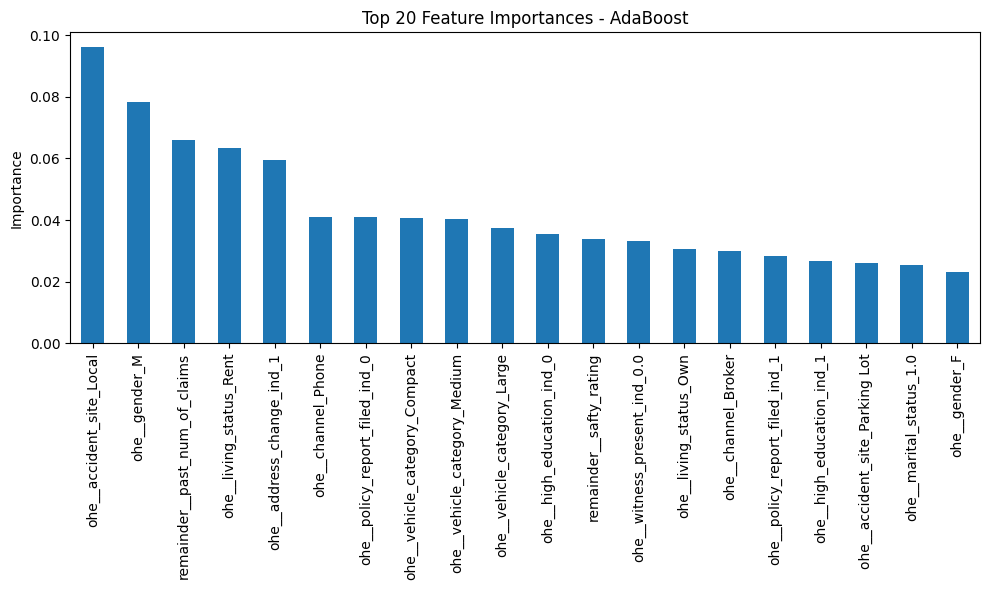

In [ ]:
import pandas as pd

# get feature importances
importances = best_ada.feature_importances_

# map to feature names
feat_importance = pd.Series(importances, index=X_train_enc.columns)

# sort descending
feat_importance = feat_importance.sort_values(ascending=False)

print("\n=== Feature Importances (AdaBoost) ===")
print(feat_importance.head(20))  # top 20

# Optional: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
feat_importance.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances - AdaBoost")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# Random forest (2)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train RF on SMOTE-resampled data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_resampled, y_resampled)

# Predict on test set
y_pred_rf = rf.predict(X_test_enc)

print("\n=== Random Forest WITH SMOTE (Test Set, Threshold=0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Predict on training set
y_pred_train_rf = rf.predict(X_resampled)

print("\n=== Random Forest WITH SMOTE (Training Set, Threshold=0.5) ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train_rf))
print(classification_report(y_resampled, y_pred_train_rf))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train_rf))



=== Random Forest WITH SMOTE (Test Set, Threshold=0.5) ===
Accuracy: 0.8433333333333334
              precision    recall  f1-score   support

           0       0.85      1.00      0.91      3034
           1       0.55      0.02      0.04       566

    accuracy                           0.84      3600
   macro avg       0.70      0.51      0.48      3600
weighted avg       0.80      0.84      0.78      3600

Confusion Matrix:
 [[3024   10]
 [ 554   12]]

=== Random Forest WITH SMOTE (Training Set, Threshold=0.5) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12148
           1       1.00      1.00      1.00     12148

    accuracy                           1.00     24296
   macro avg       1.00      1.00      1.00     24296
weighted avg       1.00      1.00      1.00     24296

Confusion Matrix:
 [[12148     0]
 [    0 12148]]


## RF with hyperparameter tuning and early regularization



In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 0.8],
    'bootstrap': [True]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_resampled, y_resampled)

print("Best RF hyperparameters:", random_search.best_params_)

best_rf = random_search.best_estimator_

# Evaluate train and test similarly using your previous thresholding method


Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
27 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Best RF hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve
import numpy as np

best_params = {
    'n_estimators': 100,
    'min_samples_split': 2,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'max_depth': None,
    'bootstrap': True,
    'random_state': 42
}

# Initialize RF with best params
tuned_rf = RandomForestClassifier(**best_params)

# Train on full SMOTE data
tuned_rf.fit(X_resampled, y_resampled)

# Predict on test set (default threshold = 0.5)
y_pred_test = tuned_rf.predict(X_test_enc)
print("\n=== Tuned RF Test Set (threshold=0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

# Predict on training set (default threshold = 0.5)
y_pred_train = tuned_rf.predict(X_resampled)
print("\n=== Tuned RF Training Set (threshold=0.5) ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train))
print(classification_report(y_resampled, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train))

# Threshold tuning on test set probabilities:
y_proba_test = tuned_rf.predict_proba(X_test_enc)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for max F1: {best_threshold:.3f}")

# Predict on test set using best threshold
y_pred_test_thresh = (y_proba_test >= best_threshold).astype(int)
print("\n=== Tuned RF Test Set (threshold tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_thresh))
print(classification_report(y_test, y_pred_test_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_thresh))

# Predict on training set using best threshold
y_proba_train = tuned_rf.predict_proba(X_resampled)[:, 1]
y_pred_train_thresh = (y_proba_train >= best_threshold).astype(int)
print("\n=== Tuned RF Training Set (threshold tuned) ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train_thresh))
print(classification_report(y_resampled, y_pred_train_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train_thresh))



=== Tuned RF Test Set (threshold=0.5) ===
Accuracy: 0.8427777777777777
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3034
           1       0.50      0.02      0.03       566

    accuracy                           0.84      3600
   macro avg       0.67      0.51      0.47      3600
weighted avg       0.79      0.84      0.78      3600

Confusion Matrix:
 [[3025    9]
 [ 557    9]]

=== Tuned RF Training Set (threshold=0.5) ===
Accuracy: 0.9778975963121501
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     12148
           1       1.00      0.96      0.98     12148

    accuracy                           0.98     24296
   macro avg       0.98      0.98      0.98     24296
weighted avg       0.98      0.98      0.98     24296

Confusion Matrix:
 [[12148     0]
 [  537 11611]]

Best threshold for max F1: 0.205

=== Tuned RF Test Set (threshold tuned) ===
Accuracy: 0.67416666666

In [31]:
from sklearn.ensemble import RandomForestClassifier

tuned_rf_reg = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,             # limit depth
    min_samples_split=10,     # require at least 10 samples to split
    min_samples_leaf=5,       # require at least 5 samples per leaf
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

tuned_rf_reg.fit(X_resampled, y_resampled)

# Evaluate
y_pred_test = tuned_rf_reg.predict(X_test_enc)
print("\n=== Regularized RF Test Set ===")
print(classification_report(y_test, y_pred_test))

y_pred_train = tuned_rf_reg.predict(X_resampled)
print("\n=== Regularized RF Training Set ===")
print(classification_report(y_resampled, y_pred_train))



=== Regularized RF Test Set ===
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3034
           1       0.50      0.01      0.02       566

    accuracy                           0.84      3600
   macro avg       0.67      0.50      0.47      3600
weighted avg       0.79      0.84      0.77      3600


=== Regularized RF Training Set ===
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     12148
           1       1.00      0.83      0.91     12148

    accuracy                           0.92     24296
   macro avg       0.93      0.92      0.92     24296
weighted avg       0.93      0.92      0.92     24296



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, accuracy_score, confusion_matrix
import numpy as np

# Define the regularized RF model
tuned_rf_reg = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,             # limit depth
    min_samples_split=10,     # require at least 10 samples to split
    min_samples_leaf=5,       # require at least 5 samples per leaf
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# Train on SMOTE-resampled data
tuned_rf_reg.fit(X_resampled, y_resampled)

# Predict on test set (default threshold = 0.5)
y_pred_test = tuned_rf_reg.predict(X_test_enc)
print("\n=== Regularized RF Test Set (threshold=0.5) ===")
print(classification_report(y_test, y_pred_test))

# Predict on training set (default threshold = 0.5)
y_pred_train = tuned_rf_reg.predict(X_resampled)
print("\n=== Regularized RF Training Set (threshold=0.5) ===")
print(classification_report(y_resampled, y_pred_train))

# Threshold tuning on test set probabilities:
y_proba_test = tuned_rf_reg.predict_proba(X_test_enc)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for max F1: {best_threshold:.3f}")

# Predict on test set using best threshold
y_pred_test_thresh = (y_proba_test >= best_threshold).astype(int)
print("\n=== Regularized RF Test Set (threshold tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_thresh))
print(classification_report(y_test, y_pred_test_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_thresh))

# Predict on training set using best threshold
y_proba_train = tuned_rf_reg.predict_proba(X_resampled)[:, 1]
y_pred_train_thresh = (y_proba_train >= best_threshold).astype(int)
print("\n=== Regularized RF Training Set (threshold tuned) ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train_thresh))
print(classification_report(y_resampled, y_pred_train_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train_thresh))



=== Regularized RF Test Set (threshold=0.5) ===
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3034
           1       0.50      0.01      0.02       566

    accuracy                           0.84      3600
   macro avg       0.67      0.50      0.47      3600
weighted avg       0.79      0.84      0.77      3600


=== Regularized RF Training Set (threshold=0.5) ===
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     12148
           1       1.00      0.83      0.91     12148

    accuracy                           0.92     24296
   macro avg       0.93      0.92      0.92     24296
weighted avg       0.93      0.92      0.92     24296


Best threshold for max F1: 0.201

=== Regularized RF Test Set (threshold tuned) ===
Accuracy: 0.6608333333333334
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      3034
           1       0.

In [34]:
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix
import numpy as np

# Predict probabilities for the positive class (fraud) on test set
y_proba_test = tuned_rf_reg.predict_proba(X_test_enc)[:, 1]

# Calculate precision, recall, and thresholds for test set
precisions_test, recalls_test, thresholds_test = precision_recall_curve(y_test, y_proba_test)

# Compute F1 scores for all thresholds
f1_scores_test = 2 * (precisions_test * recalls_test) / (precisions_test + recalls_test + 1e-10)

# Find the best threshold index (skip last point which has no threshold)
best_idx_test = np.argmax(f1_scores_test[:-1])
best_threshold_test = thresholds_test[best_idx_test]

print(f"Best threshold for max F1 (test set): {best_threshold_test:.3f}")

# Predict labels on test set using the best threshold
y_pred_test_best = (y_proba_test >= best_threshold_test).astype(int)

print("\n=== Regularized RF Test Set (Optimal Threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_best))
print(classification_report(y_test, y_pred_test_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_best))


# Repeat for training set

y_proba_train = tuned_rf_reg.predict_proba(X_resampled)[:, 1]
precisions_train, recalls_train, thresholds_train = precision_recall_curve(y_resampled, y_proba_train)
f1_scores_train = 2 * (precisions_train * recalls_train) / (precisions_train + recalls_train + 1e-10)

best_idx_train = np.argmax(f1_scores_train[:-1])
best_threshold_train = thresholds_train[best_idx_train]

print(f"\nBest threshold for max F1 (training set): {best_threshold_train:.3f}")

y_pred_train_best = (y_proba_train >= best_threshold_train).astype(int)

print("\n=== Regularized RF Training Set (Optimal Threshold) ===")
print("Accuracy:", accuracy_score(y_resampled, y_pred_train_best))
print(classification_report(y_resampled, y_pred_train_best))
print("Confusion Matrix:\n", confusion_matrix(y_resampled, y_pred_train_best))


Best threshold for max F1 (test set): 0.201

=== Regularized RF Test Set (Optimal Threshold) ===
Accuracy: 0.6608333333333334
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      3034
           1       0.26      0.61      0.36       566

    accuracy                           0.66      3600
   macro avg       0.58      0.64      0.57      3600
weighted avg       0.80      0.66      0.71      3600

Confusion Matrix:
 [[2031 1003]
 [ 218  348]]

Best threshold for max F1 (training set): 0.297

=== Regularized RF Training Set (Optimal Threshold) ===
Accuracy: 0.9631215014817254
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     12148
           1       0.97      0.96      0.96     12148

    accuracy                           0.96     24296
   macro avg       0.96      0.96      0.96     24296
weighted avg       0.96      0.96      0.96     24296

Confusion Matrix:
 [[11734   414]
 [  4